In [1]:
import os
from pathlib import Path
import pandas as pd
import muon as mu

/home/emoeller/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
mm10_gene_info_df = pd.read_csv("./data/cell_context_encoder/Mus_musculus.gene_info.gz", sep="\t", compression="gzip", header=0)
mm10_gene_info_df.head()

,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type
0,10090,11287,Pzp2,-,A1m|A2m|MAM|Pzp,MGI:MGI:87854|Ensembl:ENSMUSG00000030359|Allia...,6,6 F3|6 63.02 cM,PZP alpha-2-macroglobulin like 2,protein-coding,Pzp2,PZP alpha-2-macroglobulin like 2,O,"pregnancy zone protein|PZP, alpha-2-macroglobu...",20250924,-
1,10090,11298,Aanat,-,AA-NAT|Nat-2|Nat4|Snat,MGI:MGI:1328365|Ensembl:ENSMUSG00000020804|All...,11,11 81.43 cM|11 E2,arylalkylamine N-acetyltransferase,protein-coding,Aanat,arylalkylamine N-acetyltransferase,O,serotonin N-acetyltransferase|aralkylamine N-a...,20250930,-
2,10090,11302,Aatk,-,AATYK|aatyk1|mKIAA0641,MGI:MGI:1197518|Ensembl:ENSMUSG00000025375|All...,11,11 E2|11 83.96 cM,apoptosis-associated tyrosine kinase,protein-coding,Aatk,apoptosis-associated tyrosine kinase,O,serine/threonine-protein kinase LMTK1|apoptosi...,20250924,-
3,10090,11303,Abca1,-,ABC-1|Abc1,MGI:MGI:99607|Ensembl:ENSMUSG00000015243|Allia...,4,4 B2|4 28.57 cM,"ATP-binding cassette, sub-family A member 1",protein-coding,Abca1,"ATP-binding cassette, sub-family A member 1",O,phospholipid-transporting ATPase ABCA1|ATP-bin...,20250930,-
4,10090,11304,Abca4,-,Abc10|Abcr|D430003I15Rik|RmP,MGI:MGI:109424|Ensembl:ENSMUSG00000028125|Alli...,3,3 G1|3 52.94 cM,"ATP-binding cassette, sub-family A member 4",protein-coding,Abca4,"ATP-binding cassette, sub-family A member 4",O,retinal-specific phospholipid-transporting ATP...,20250924,-


In [3]:
gene_tss_df = pd.read_csv("./data/cell_context_encoder/mm10_gene_tss.bed", sep="\t", names=["chr", "start", "end", "Symbol"])
gene_tss_df.head()

,chr,start,end,Symbol
0,chrY,31419544,31419545,Gm28489
1,chrY,68409633,68409634,Gm21867
2,chrY,68446562,68446563,Gm29448
3,chrY,68549224,68549225,Gm20816
4,chrY,68550741,68550742,Gm20816


In [4]:
mdata = mu.read("./data/cell_context_encoder/multiome_processed.h5mu")
mdata

/home/emoeller/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/mudata/_core/mudata.py:1471: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/emoeller/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/mudata/_core/mudata.py:1322: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 6832 × 215552
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
  2 modalities
    rna:	6832 × 18637
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'celltype'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
      obsm:	'X_pca', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	6832 × 196915
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'NS', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'nearest_gene', 'TSS_dist', 'TSS_dist_score'
      uns:	'files', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'peak_gene_distance_params', 'peak_gene_links', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

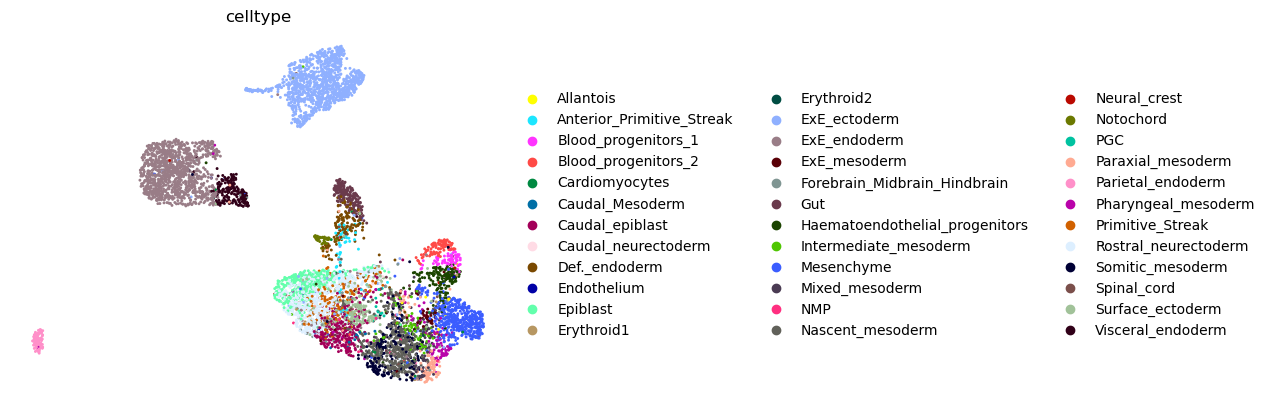

In [5]:
import scanpy as sc

sc.pl.umap(
    mdata.mod["rna"],
    color=["celltype"],
    vmax="p99",
    frameon=False,
)

In [6]:
barcode_celltype_map = mdata.mod["rna"].obs["celltype"]
sparse_distance_matrix = mdata.mod["rna"].obsp["distances"]

In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy import sparse
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def build_celltype_network(
    barcode_celltype_map,
    sparse_distance_matrix,
    min_connections=10,
    include_within_celltype=False,
):
    """
    Collapse a sparse cell-cell distance graph into a cell-type network.

    Parameters
    ----------
    barcode_celltype_map
        pandas Series indexed by barcode. Its order must match the rows and
        columns of sparse_distance_matrix.
    sparse_distance_matrix
        Sparse cell-cell distance matrix. Nonzero entries represent graph edges.
    min_connections
        Minimum number of cell-cell connections required for a cell-type edge.
    include_within_celltype
        Whether to retain self-edges between cells of the same cell type.
    """
    celltypes = pd.Series(barcode_celltype_map).astype("string")

    if sparse_distance_matrix.shape[0] != len(celltypes):
        raise ValueError(
            "The number of cell types does not match the distance matrix: "
            f"{len(celltypes)} labels versus "
            f"{sparse_distance_matrix.shape[0]} matrix rows."
        )

    # Use COO so only stored, nonzero distances are processed.
    distance_coo = sparse_distance_matrix.tocoo(copy=False)

    edge_df = pd.DataFrame(
        {
            "source_celltype": celltypes.iloc[distance_coo.row].to_numpy(),
            "target_celltype": celltypes.iloc[distance_coo.col].to_numpy(),
            "distance": distance_coo.data,
        }
    )

    # Remove missing annotations and diagonal cell-cell entries.
    valid = (
        edge_df["source_celltype"].notna()
        & edge_df["target_celltype"].notna()
        & (distance_coo.row != distance_coo.col)
        & np.isfinite(edge_df["distance"])
        & (edge_df["distance"] > 0)
    )
    edge_df = edge_df.loc[valid].copy()

    if not include_within_celltype:
        edge_df = edge_df[
            edge_df["source_celltype"] != edge_df["target_celltype"]
        ].copy()

    # Canonical ordering makes A-B and B-A the same cell-type edge.
    source = edge_df["source_celltype"].astype(str).to_numpy()
    target = edge_df["target_celltype"].astype(str).to_numpy()

    edge_df["celltype_1"] = np.minimum(source, target)
    edge_df["celltype_2"] = np.maximum(source, target)

    edge_summary = (
        edge_df.groupby(["celltype_1", "celltype_2"], observed=True)
        .agg(
            n_connections=("distance", "size"),
            mean_distance=("distance", "mean"),
            median_distance=("distance", "median"),
        )
        .reset_index()
    )

    edge_summary = edge_summary[
        edge_summary["n_connections"] >= min_connections
    ].copy()

    # Similarity is useful for spring_layout: closer cell types attract more.
    edge_summary["similarity"] = 1.0 / (
        edge_summary["mean_distance"] + 1e-8
    )

    celltype_counts = celltypes.value_counts()

    graph = nx.Graph()

    for celltype, count in celltype_counts.items():
        graph.add_node(str(celltype), n_cells=int(count))

    for row in edge_summary.itertuples(index=False):
        graph.add_edge(
            row.celltype_1,
            row.celltype_2,
            n_connections=int(row.n_connections),
            mean_distance=float(row.mean_distance),
            median_distance=float(row.median_distance),
            similarity=float(row.similarity),
        )

    return graph, edge_summary

In [14]:
barcode_celltype_map = mdata.mod["rna"].obs["celltype"]
sparse_distance_matrix = mdata.mod["rna"].obsp["distances"]



G, celltype_edges = build_celltype_network(
    barcode_celltype_map=barcode_celltype_map,
    sparse_distance_matrix=sparse_distance_matrix,
    min_connections=20,
)

celltype_counts = barcode_celltype_map.value_counts()

celltype_edges["connection_fraction"] = celltype_edges.apply(
    lambda row: row["n_connections"]
    / (
        celltype_counts[row["celltype_1"]]
        * celltype_counts[row["celltype_2"]]
    ),
    axis=1,
)


display(celltype_edges.sort_values("connection_fraction", ascending=False))

,celltype_1,celltype_2,n_connections,mean_distance,median_distance,similarity,connection_fraction
89,Caudal_Mesoderm,Caudal_epiblast,181,6.734408,6.678432,0.148491,0.045523
1,Allantois,Blood_progenitors_1,24,6.213469,6.307071,0.160941,0.041026
21,Anterior_Primitive_Streak,Def._endoderm,281,7.658256,7.637224,0.130578,0.039566
40,Blood_progenitors_1,Blood_progenitors_2,236,6.467943,6.446787,0.154609,0.038625
315,Haematoendothelial_progenitors,Neural_crest,40,6.651650,6.751729,0.150339,0.035492
...,...,...,...,...,...,...,...
241,ExE_ectoderm,Visceral_endoderm,21,7.698558,7.827101,0.129894,0.000096
107,Caudal_epiblast,ExE_ectoderm,32,6.566611,6.478528,0.152286,0.000095
224,ExE_ectoderm,ExE_endoderm,99,6.093866,5.767155,0.164099,0.000074
247,ExE_endoderm,Mesenchyme,39,7.533872,7.531736,0.132734,0.000067


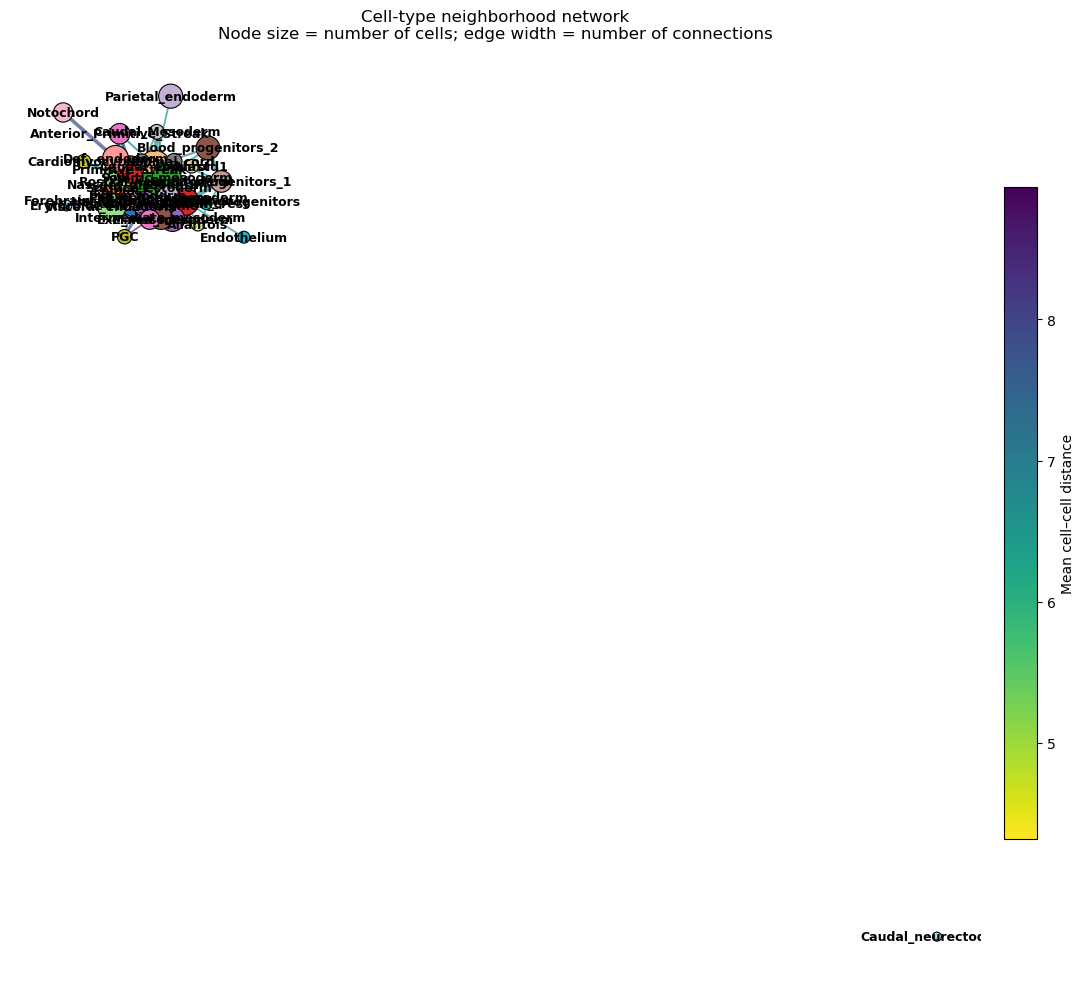

In [19]:
def plot_celltype_network(
    G,
    figsize=(12, 10),
    seed=42,
    node_scale=30,
    max_edge_width=8,
):
    if G.number_of_nodes() == 0:
        raise ValueError("The graph contains no nodes.")

    if G.number_of_edges() == 0:
        raise ValueError(
            "The graph contains no edges. Try reducing min_connections."
        )

    node_counts = np.array(
        [G.nodes[node]["n_cells"] for node in G.nodes()],
        dtype=float,
    )

    # Square-root scaling prevents abundant cell types from dominating.
    node_sizes = node_scale * np.sqrt(node_counts)

    connection_counts = np.array(
        [G[u][v]["n_connections"] for u, v in G.edges()],
        dtype=float,
    )
    mean_distances = np.array(
        [G[u][v]["mean_distance"] for u, v in G.edges()],
        dtype=float,
    )

    edge_widths = (
        0.5
        + max_edge_width
        * np.sqrt(connection_counts / connection_counts.max())
    )

    # Create robust layout weights without modifying the reported distances
    edge_distances = np.array(
        [G[u][v]["mean_distance"] for u, v in G.edges()],
        dtype=float,
    )

    # Prevent one extreme distance from dominating the layout
    lower, upper = np.percentile(edge_distances, [5, 90])
    distance_scale = max(np.median(edge_distances), 1e-8)

    for u, v in G.edges():
        clipped_distance = np.clip(
            G[u][v]["mean_distance"],
            lower,
            upper,
        )

        # Close cell types have stronger attraction.
        # The small floor prevents distant nodes from becoming nearly disconnected.
        G[u][v]["layout_weight"] = (
            0.05 + np.exp(-clipped_distance / distance_scale)
        )

    # A larger k spreads the central cluster out
    pos = nx.spring_layout(
        G,
        weight="layout_weight",
        seed=42,
        k=5 / np.sqrt(G.number_of_nodes()),
        iterations=1000,
    )

    fig, ax = plt.subplots(figsize=figsize)

    distance_norm = Normalize(
        vmin=mean_distances.min(),
        vmax=mean_distances.max(),
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        width=edge_widths,
        edge_color=mean_distances,
        edge_cmap=plt.cm.viridis_r,
        edge_vmin=mean_distances.min(),
        edge_vmax=mean_distances.max(),
        alpha=0.7,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=np.arange(G.number_of_nodes()),
        cmap=plt.cm.tab20,
        edgecolors="black",
        linewidths=0.8,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=9,
        font_weight="bold",
    )

    colorbar = fig.colorbar(
        ScalarMappable(norm=distance_norm, cmap=plt.cm.viridis_r),
        ax=ax,
        shrink=0.7,
        pad=0.02,
    )
    colorbar.set_label("Mean cell–cell distance")

    ax.set_title(
        "Cell-type neighborhood network\n"
        "Node size = number of cells; edge width = number of connections"
    )
    ax.axis("off")
    fig.tight_layout()

    return fig, ax, pos


fig, ax, pos = plot_celltype_network(G)
plt.show()